# Exploration Notebook
## Letterboxd Dashboard
### Reid B.

In [54]:
#pip install matplotlib
#pip install pandas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ratings = pd.read_csv("data/ratings.csv")
diary = pd.read_csv("data/diary.csv")
watched = pd.read_csv("data/watched.csv")
watchlist = pd.read_csv("data/watchlist.csv")

In [3]:
print(ratings.shape)
print(diary.shape)
print(watched.shape)
print(watchlist.shape)

print(ratings.columns.tolist())
print(diary.columns.tolist())
print(watched.columns.tolist())
print(watchlist.columns.tolist())

(761, 5)
(906, 8)
(1230, 4)
(911, 4)
['Date', 'Name', 'Year', 'Letterboxd URI', 'Rating']
['Date', 'Name', 'Year', 'Letterboxd URI', 'Rating', 'Rewatch', 'Tags', 'Watched Date']
['Date', 'Name', 'Year', 'Letterboxd URI']
['Date', 'Name', 'Year', 'Letterboxd URI']


In [4]:
# Basic stats
print(f"Total films rated: {len(ratings)}")
print(f"Diary entries: {len(diary)}")
ratings["Rating"].describe()
#diary["Rating"].describe()

Total films rated: 761
Diary entries: 906


count    761.000000
mean       3.420499
std        0.988380
min        0.500000
25%        3.000000
50%        3.500000
75%        4.000000
max        5.000000
Name: Rating, dtype: float64

In [5]:
# Your rating distribution
ratings["Rating"].value_counts().sort_index()

Rating
0.5      8
1.0     18
1.5     24
2.0     52
2.5     54
3.0    145
3.5    141
4.0    171
4.5     93
5.0     55
Name: count, dtype: int64

In [6]:
# What's my most watched year of film?
ratings["Year"].value_counts().head(10)

Year
2023    74
2025    69
2024    67
2022    31
2017    29
2019    27
2014    24
2021    19
2013    18
2015    16
Name: count, dtype: int64

In [7]:
# Do I rate older films higher?
ratings.groupby("Year")["Rating"].mean().sort_values(ascending=False).head(10)

Year
1924    5.000000
1952    5.000000
1966    5.000000
1960    5.000000
1975    4.750000
1931    4.500000
1959    4.500000
1964    4.500000
1976    4.500000
1989    4.416667
Name: Rating, dtype: float64

In [8]:
# Average rating by decade
ratings["Decade"] = (ratings["Year"] // 10) * 10
ratings.groupby("Decade")["Rating"].mean().sort_values(ascending=False).head(10)

Decade
1930    4.500000
1950    4.428571
1920    4.250000
1960    4.000000
1970    3.937500
1980    3.860000
1940    3.750000
2000    3.619658
1990    3.618421
2010    3.260989
Name: Rating, dtype: float64

In [9]:
# How many films do I log per month?
diary["Date"] = pd.to_datetime(diary["Date"])
diary.groupby(diary["Date"].dt.to_period("M")).size()

Date
2022-09     6
2022-10     1
2022-11     3
2022-12    13
2023-01    14
2023-02    13
2023-03    15
2023-04    17
2023-05    38
2023-06    20
2023-07    54
2023-08    16
2023-09    13
2023-10    27
2023-11    20
2023-12    30
2024-01    18
2024-02     9
2024-03     7
2024-04     4
2024-05    22
2024-06    38
2024-07    15
2024-08    15
2024-09    38
2024-10     9
2024-11    19
2024-12    24
2025-01    24
2025-02    41
2025-03    20
2025-04    10
2025-05    17
2025-06    23
2025-07    18
2025-08    46
2025-09    14
2025-10    12
2025-11    21
2025-12    28
2026-01    33
2026-02    19
2026-03    30
2026-04    25
2026-05     7
Freq: M, dtype: int64

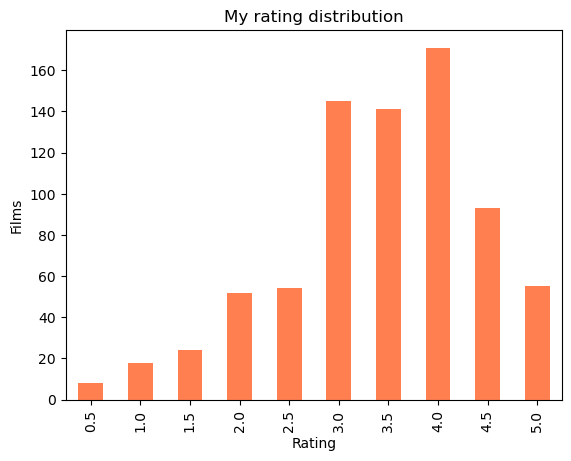

In [10]:


rating_counts = ratings["Rating"].value_counts().sort_index()
rating_counts.plot(kind="bar", color="coral")
plt.title("My rating distribution")
plt.xlabel("Rating")
plt.ylabel("Films")
plt.show()